# Audit of Fake News Detection Model
### By: Jack Hariri and Noga Gottlieb
### New York University (Spring 2026)
### Auditing https://huggingface.co/hamzab/roberta-fake-news-classification 


## Model Setup
Load the pretrained RoBERTa fake-news classifier and the packages used throughout the audit.


In [1]:
#importing the necessary libraries and loading the pre-trained model

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("hamzab/roberta-fake-news-classification")

model = AutoModelForSequenceClassification.from_pretrained("hamzab/roberta-fake-news-classification")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Prediction Helper
Define one reusable function that formats an article, runs the model, and returns fake/real probabilities.


In [2]:
#function to predict if the news is fake or real
def predict_fake(title,text):
    input_str = "<title>" + title + "<content>" +  text + "<end>"
    input_ids = tokenizer(
        input_str, 
        max_length=512, 
        padding="max_length", 
        truncation=True, 
        return_tensors="pt"
    )
    device =  'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    with torch.no_grad():
        output = model(input_ids["input_ids"].to(device), attention_mask=input_ids["attention_mask"].to(device))
    return dict(zip(["Fake","Real"], [x.item() for x in list(torch.nn.Softmax()(output.logits)[0])] ))
    

## Source Data
Load the fake and real news article datasets used for initial model checks.


In [3]:
#loading the datasets
fake_news = pd.read_csv(
    "Fake.csv",
    engine="python",      
    quotechar='"',
    escapechar='\\',     
    on_bad_lines="skip"   
)
real_news = pd.read_csv(
    "True.csv",
    engine="python",   
    quotechar='"',
    escapechar='\\',      #
    on_bad_lines="skip"   
)

fake_news = fake_news.assign(true_label=0)
real_news = real_news.assign(true_label=1)

In [4]:
#creating a dictionary to store the results of the predictions
fake_news_results = {'fake': [],
                     'real': []}

original_set = pd.concat([real_news, fake_news], ignore_index=True)

In [5]:
#predicting if the news is fake or real and storing the results in the dictionary
sampled_set = original_set.sample(frac=0.05, random_state=67).reset_index(drop=True)

for _, article in sampled_set.iterrows():
    result = predict_fake(article['title'], article['text'])
    fake_news_results['fake'].append(result['Fake'])
    fake_news_results['real'].append(result['Real'])
    
sampled_set['fake_prob'] = fake_news_results['fake']
sampled_set['real_prob'] = fake_news_results['real']
sampled_set['pred_label'] = np.where(sampled_set['fake_prob'] > sampled_set['real_prob'], 0, 1)

print (sum(fake_news_results['fake'])/len(fake_news_results['fake']))

/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0.5051334706789882


In [6]:
from fairlearn.metrics import MetricFrame
import fairlearn.datasets as fdata
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)
from sklearn.metrics import accuracy_score, precision_score, recall_score

fairlearn_metrics = {
    'accuracy': accuracy_score,
    'precision': lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
    'recall': lambda y_true, y_pred: recall_score(y_true, y_pred, zero_division=0),
    'false_negative_rate': false_negative_rate,
    'false_positive_rate': false_positive_rate,
}

mf = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=sampled_set['true_label'],
    y_pred=sampled_set['pred_label'],
    sensitive_features=sampled_set['subject']
)

print("--- Metrics Overall ---")
display(mf.overall)

--- Metrics Overall ---


accuracy               1.0
precision              1.0
recall                 1.0
false_negative_rate    0.0
false_positive_rate    0.0
dtype: float64

In [7]:
reuters_count = real_news['text'].str.contains('Reuters').sum()
overall_count = len(real_news)

print(f"Number of articles in Real News: {overall_count}")
print(f"Number of articles containing 'Reuters': {reuters_count}")
print("prectanges out overall: " , reuters_count/overall_count)

Number of articles in Real News: 21417


Number of articles containing 'Reuters': 21378
prectanges out overall:  0.9981790166690012


## LIAR Test Set
Define the LIAR column names, load the TSV test split, and preview a small sample.


In [8]:
#function to predict if the news is fake or real
def predict_fake_LIAR(title,text):
    input_str = text
    input_ids = tokenizer(
        input_str, 
        max_length=512, 
        padding="max_length", 
        truncation=True, 
        return_tensors="pt"
    )
    device =  'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    with torch.no_grad():
        output = model(input_ids["input_ids"].to(device), attention_mask=input_ids["attention_mask"].to(device))
    return dict(zip(["Fake","Real"], [x.item() for x in list(torch.nn.Softmax()(output.logits)[0])] ))

In [9]:
#loading the test dataset columns
columns = [
    "id",
    "label",
    "statement",
    "subjects",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_count",
    "false_count",
    "half_true_count",
    "mostly_true_count",
    "pants_on_fire_count",
    "context"
]

In [10]:
#loading the test dataset
newstotest = pd.read_csv(
    "test.tsv",
    sep="\t",
    header=None,     
    names=columns   
)

fake_news_test = newstotest.head(10)
display(fake_news_test)

,id,label,statement,subjects,speaker,job_title,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_on_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video
5,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,NaN,Rhode Island,republican,1,2,1,1,0,a campaign website
6,7070.json,true,Says that Tennessee law requires that schools ...,"county-budget,county-government,education,taxes",stand-children-tennessee,Child and education advocacy organization.,Tennessee,none,0,0,0,0,0,in a post on Facebook.
7,1046.json,barely-true,"Says Vice President Joe Biden ""admits that the...","economy,stimulus",john-boehner,Speaker of the House of Representatives,Ohio,republican,13,22,11,4,2,a press release.
8,12849.json,true,Donald Trump is against marriage equality. He ...,"gays-and-lesbians,marriage",sean-patrick-maloney,Congressman for NY-18,New York,democrat,0,0,0,0,0,a speech at the Democratic National Convention
9,13270.json,barely-true,We know that more than half of Hillary Clinton...,foreign-policy,mike-pence,Governor,Indiana,republican,8,10,12,5,0,"comments on ""Meet the Press"""


In [11]:
#preview model predictions on a small LIAR test sample
for _, article in fake_news_test.iterrows():
    result = predict_fake_LIAR(str(article['context']), article['statement'])
    fake_news_results['fake'].append(result['Fake'])
    fake_news_results['real'].append(result['Real'])
    print(f"Statement: {article['statement']}, Prediction: {result['Real']}, True Value: {article['label']}")
    
print (sum(fake_news_results['fake'])/len(fake_news_results['fake']))

/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Statement: Building a wall on the U.S.-Mexico border will take literally years., Prediction: 0.9999104738235474, True Value: true
Statement: Wisconsin is on pace to double the number of layoffs this year., Prediction: 0.9999163150787354, True Value: false


Statement: Says John McCain has done nothing to help the vets., Prediction: 0.0008580220746807754, True Value: false
Statement: Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors., Prediction: 0.9996377229690552, True Value: half-true


Statement: When asked by a reporter whether hes at the center of a criminal scheme to violate campaign laws, Gov. Scott Walker nodded yes., Prediction: 0.520537257194519, True Value: pants-fire
Statement: Over the past five years the federal government has paid out $601 million in retirement and disability benefits to deceased former federal employees., Prediction: 0.9998948574066162, True Value: true


Statement: Says that Tennessee law requires that schools receive half of proceeds -- $31 million per year -- from a half-cent increase in the Shelby County sales tax., Prediction: 0.9995959401130676, True Value: true
Statement: Says Vice President Joe Biden "admits that the American people are being scammed" with the economic stimulus package., Prediction: 0.00025141536025330424, True Value: barely-true


Statement: Donald Trump is against marriage equality. He wants to go back., Prediction: 0.0003370397025719285, True Value: true
Statement: We know that more than half of Hillary Clintons meetings while she was secretary of state were given to major contributors to the Clinton Foundation., Prediction: 0.0020733666606247425, True Value: barely-true
0.504878771251234


## Binary Labels and Model Scores
Convert LIAR labels to a binary target and score the filtered examples with the classifier.


In [12]:
#map LIAR truth labels into binary real/fake labels
label_mapping = {
    'true': 1,
    'mostly-true': 1, 
    'false': 0,
    'pants-fire': 0,
    'barely-true': 0,
    'half-true': None
}

newstotest['true_label'] = newstotest['label'].map(label_mapping)
clear_news_to_test = newstotest.dropna(subset=['true_label']).copy()

# Convert to integer so metrics work correctly
clear_news_to_test.loc[:, 'true_label'] = clear_news_to_test['true_label'].astype(int)


In [13]:
#run predictions for the filtered LIAR test examples
preds = []
pred_labels = []
for index, article in clear_news_to_test.iterrows():
    result = predict_fake_LIAR(str(article['context']), article['statement'])
    real_score = result['Real']
    label = 1 if real_score > 0.5 else 0
    preds.append(real_score)
    pred_labels.append(label)

clear_news_to_test.loc[:, 'pred'] = preds
clear_news_to_test.loc[:, 'pred_label'] = pred_labels


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [14]:
#preview the scored LIAR test data
clear_news_to_test.head(10)
print(clear_news_to_test.value_counts('pred_label'))
print(clear_news_to_test.value_counts('true_label'))

pred_label
1    561
0    441
Name: count, dtype: int64
true_label
0.0    553
1.0    449
Name: count, dtype: int64


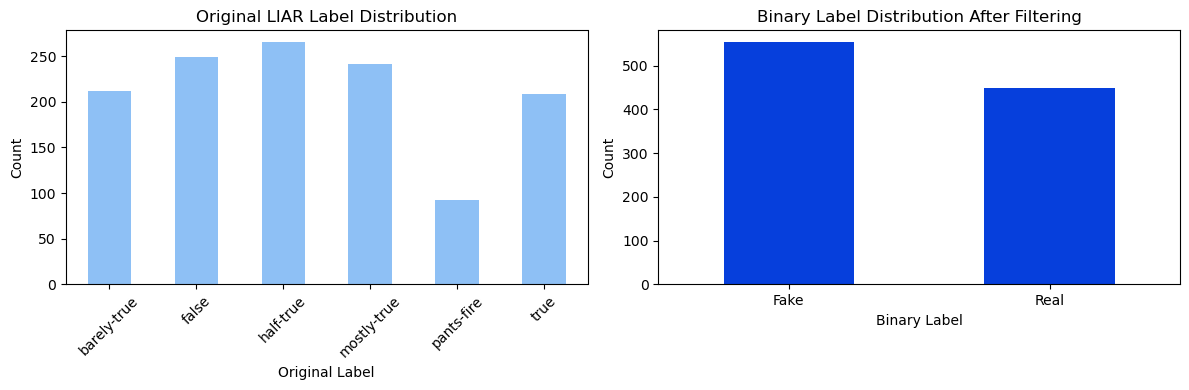

In [15]:
#plot original and binary label distributions for the LIAR test data
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

newstotest['label'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    color="#8EC0F5",
    title='Original LIAR Label Distribution'
)
axes[0].set_xlabel('Original Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

binary_label_counts = clear_news_to_test['true_label'].map({
    0: 'Fake',
    1: 'Real'
}).value_counts().reindex(['Fake', 'Real'])

binary_label_counts.plot(
    kind='bar',
    ax=axes[1],
    color="#063FDC",
    title='Binary Label Distribution After Filtering'
)
axes[1].set_xlabel('Binary Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Fairness Audit Across Parties
Use Fairlearn to compute group metrics and disparity measures by party affiliation.


In [16]:
#calculate overall fairness metrics across party affiliation groups
mf = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=clear_news_to_test['true_label'],
    y_pred=clear_news_to_test['pred_label'],
    sensitive_features=clear_news_to_test['party_affiliation']
)

print("--- Metrics Overall ---")
display(mf.overall)

print("--- Metrics by Political Party ---")
display(mf.by_group)

fairness_disparities = pd.Series({
    'FNR difference': false_negative_rate_difference(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'FPR difference': false_positive_rate_difference(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'Demographic parity ratio': demographic_parity_ratio(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'Equalized odds ratio': equalized_odds_ratio(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
    'Selection rate difference': selection_rate_difference(
        clear_news_to_test['true_label'],
        clear_news_to_test['pred_label'],
        sensitive_features=clear_news_to_test['party_affiliation']
    ),
})

print("\n--- Fairness Disparity Metrics by Political Party ---")
display(fairness_disparities)

--- Metrics Overall ---


accuracy               0.540918
precision              0.490196
recall                 0.612472
false_negative_rate    0.387528
false_positive_rate    0.517179
dtype: float64

--- Metrics by Political Party ---


,accuracy,precision,recall,false_negative_rate,false_positive_rate
party_affiliation,,,,,
activist,1.000000,1.000000,1.000000,0.000000,0.000000
business-leader,1.000000,1.000000,1.000000,0.000000,0.000000
columnist,0.285714,0.333333,0.666667,0.333333,1.000000
constitution-party,1.000000,0.000000,0.000000,0.000000,0.000000
county-commissioner,1.000000,0.000000,0.000000,0.000000,0.000000
democrat,0.557994,0.622222,0.605405,0.394595,0.507463
independent,0.461538,0.444444,0.666667,0.333333,0.714286
journalist,0.500000,0.750000,0.500000,0.500000,0.500000
libertarian,0.750000,1.000000,0.500000,0.500000,0.000000



--- Fairness Disparity Metrics by Political Party ---


FNR difference               0.666667
FPR difference               1.000000
Demographic parity ratio     0.000000
Equalized odds ratio         0.000000
Selection rate difference    1.000000
dtype: float64

## Democrat vs. Republican Audit
Focus the fairness comparison on Democrat and Republican examples only.


In [17]:

filtered_news = clear_news_to_test[
    clear_news_to_test['party_affiliation'].isin(['democrat', 'republican'])
].copy()

mf_political = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=filtered_news['true_label'],
    y_pred=filtered_news['pred_label'],
    sensitive_features=filtered_news['party_affiliation']
)

political_disparities = pd.Series({
    'FNR difference': false_negative_rate_difference(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'FPR difference': false_positive_rate_difference(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'Demographic parity ratio': demographic_parity_ratio(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'Equalized odds ratio': equalized_odds_ratio(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
    'Selection rate difference': selection_rate_difference(
        filtered_news['true_label'],
        filtered_news['pred_label'],
        sensitive_features=filtered_news['party_affiliation']
    ),
})

print("Political Bias Audit: Democrat vs. Republican")
display(mf_political.by_group)

print("\nDisparity Metrics: Democrat vs. Republican")
display(political_disparities)

Political Bias Audit: Democrat vs. Republican


,accuracy,precision,recall,false_negative_rate,false_positive_rate
party_affiliation,,,,,
democrat,0.557994,0.622222,0.605405,0.394595,0.507463
republican,0.534247,0.436975,0.597701,0.402299,0.507576



Disparity Metrics: Democrat vs. Republican


FNR difference               0.007704
FPR difference               0.000113
Demographic parity ratio     0.962988
Equalized odds ratio         0.987274
Selection rate difference    0.020884
dtype: float64

## Fairness Visualizations
Plot the party-level fairness metrics to make the disparities easier to compare.


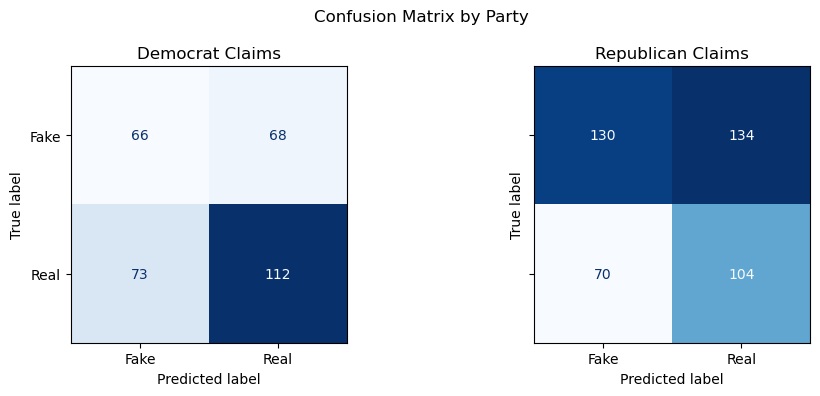

In [18]:
#plot confusion matrices separately for Democrat and Republican claims
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, party in zip(axes, ['democrat', 'republican']):
    party_data = filtered_news[filtered_news['party_affiliation'] == party]
    cm = confusion_matrix(
        party_data['true_label'],
        party_data['pred_label'],
        labels=[0, 1]
    )
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fake', 'Real']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'{party.title()} Claims')

fig.suptitle('Confusion Matrix by Party')
plt.tight_layout()
plt.show()


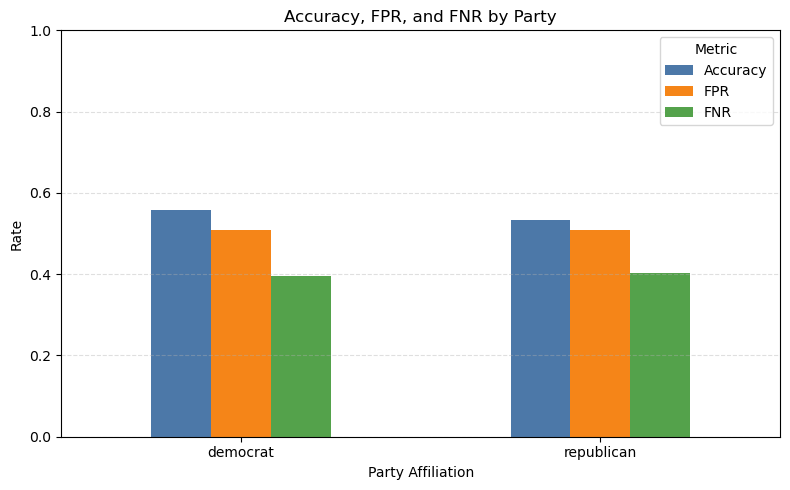

In [19]:
#plot accuracy, false positive rate, and false negative rate by party
core_metrics = mf_political.by_group[
    ['accuracy', 'false_positive_rate', 'false_negative_rate']
].rename(columns={
    'accuracy': 'Accuracy',
    'false_positive_rate': 'FPR',
    'false_negative_rate': 'FNR'
})

ax = core_metrics.plot(
    kind='bar',
    figsize=(8, 5),
    rot=0,
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title('Accuracy, FPR, and FNR by Party')
plt.xlabel('Party Affiliation')
plt.ylabel('Rate')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


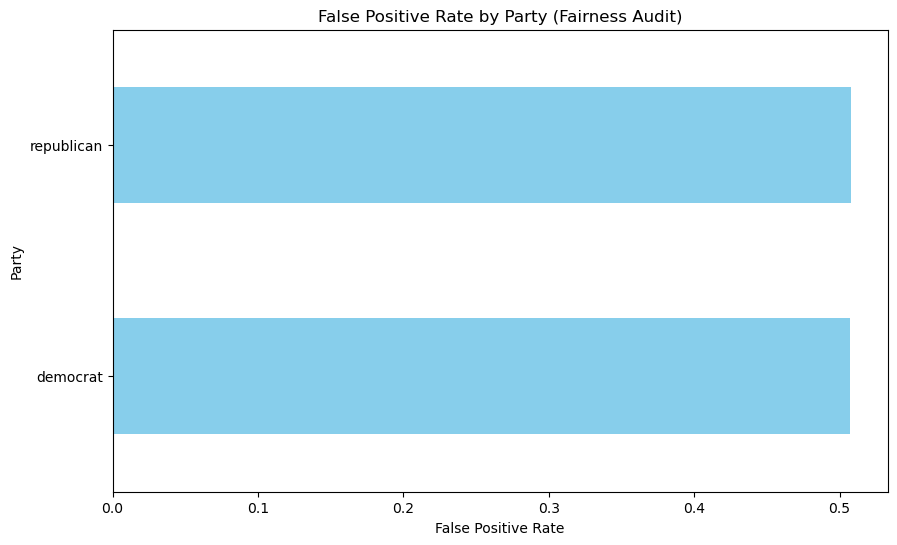

In [20]:
#visualize false positive rate by political party
import matplotlib.pyplot as plt

# Plotting False Positive Rate by Group
mf_political.by_group['false_positive_rate'].sort_values().plot(
    kind='barh', 
    figsize=(10, 6), 
    color='skyblue',
    title='False Positive Rate by Party (Fairness Audit)'
)
plt.xlabel('False Positive Rate')
plt.ylabel('Party')
plt.show()

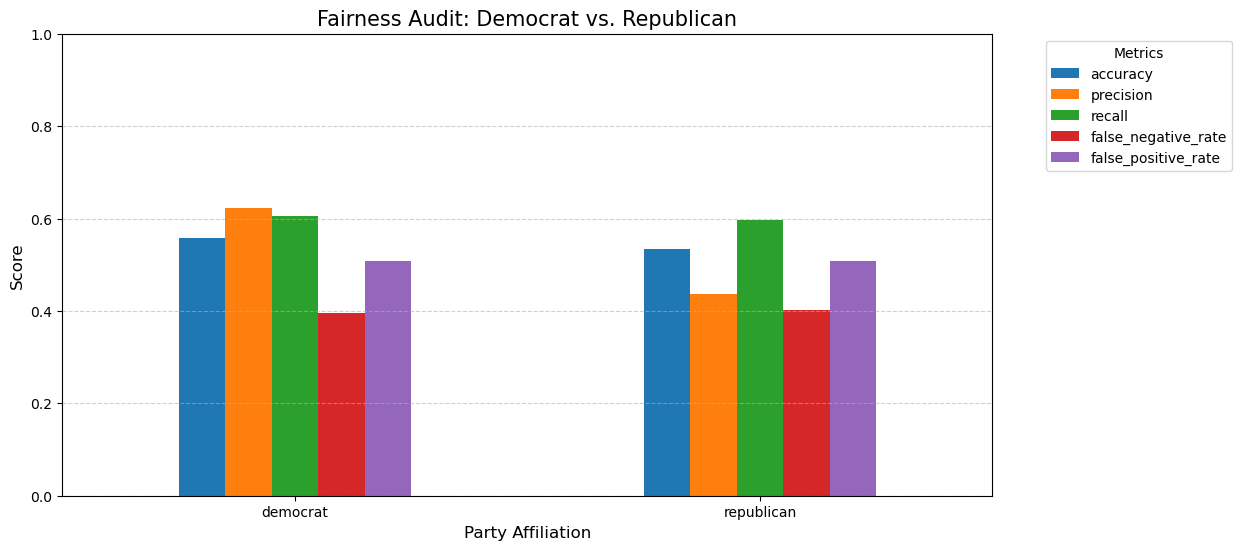

In [21]:
#visualize all fairness metrics by political party
import matplotlib.pyplot as plt

# Plot all metrics side-by-side
ax = mf_political.by_group.plot(
    kind='bar', 
    figsize=(12, 6), 
    rot=0,
    ylim=(0, 1) # Metrics are between 0 and 1
)

plt.title("Fairness Audit: Democrat vs. Republican", fontsize=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Party Affiliation", fontsize=12)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

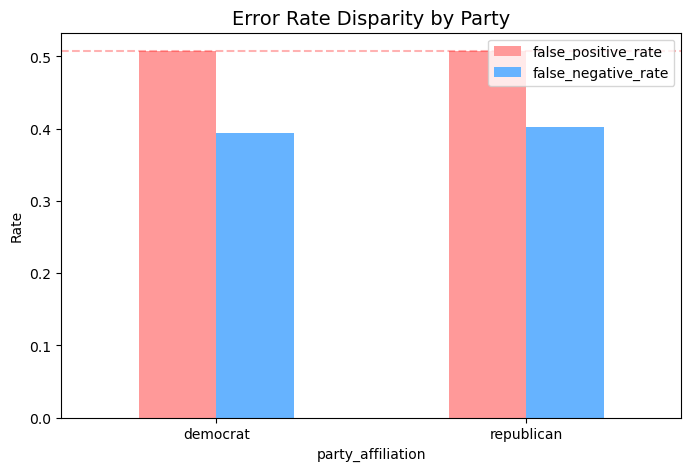

In [22]:
# Focus specifically on error rates
error_metrics = mf_political.by_group[['false_positive_rate', 'false_negative_rate']]

error_metrics.plot(
    kind='bar', 
    color=['#ff9999','#66b3ff'], 
    figsize=(8, 5),
    rot=0
)

plt.title("Error Rate Disparity by Party", fontsize=14)
plt.ylabel("Rate")
plt.axhline(y=error_metrics.loc['democrat', 'false_positive_rate'], color='red', linestyle='--', alpha=0.3)
plt.show()

## SHAP Error Explanation
Inspect one misclassified Republican example to see which words pushed the model prediction.


Generating SHAP plots for 6 examples...

Example 1
True: Fake | Pred: Real


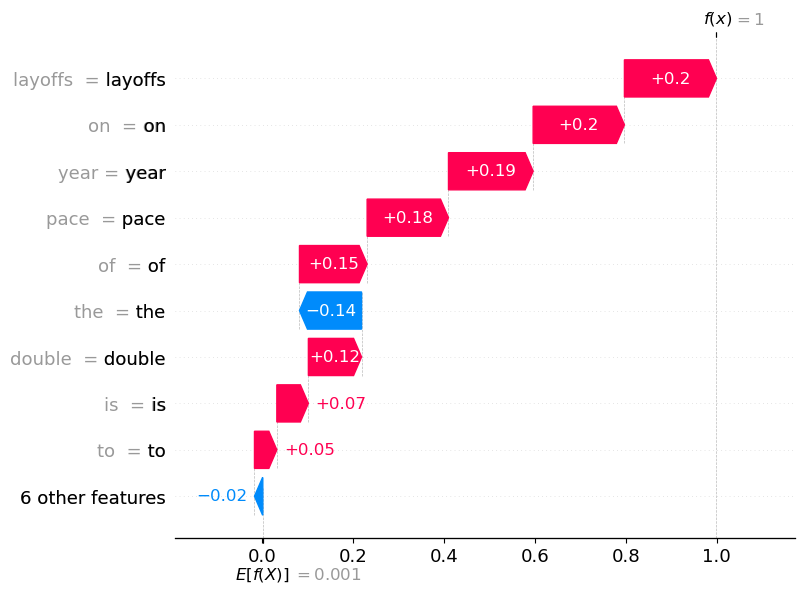


Example 2
True: Fake | Pred: Real


  0%|          | 0/498 [00:00<?, ?it/s]

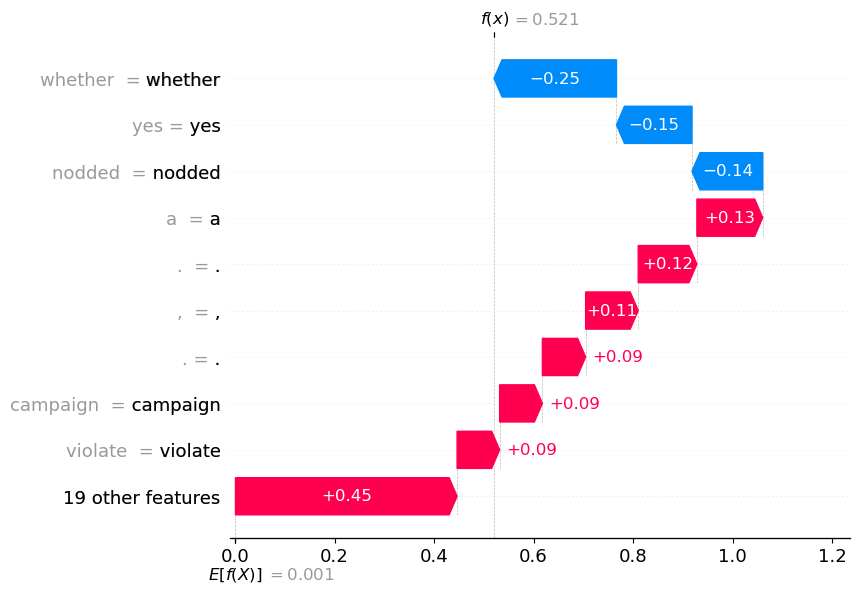


Example 3
True: Real | Pred: Fake


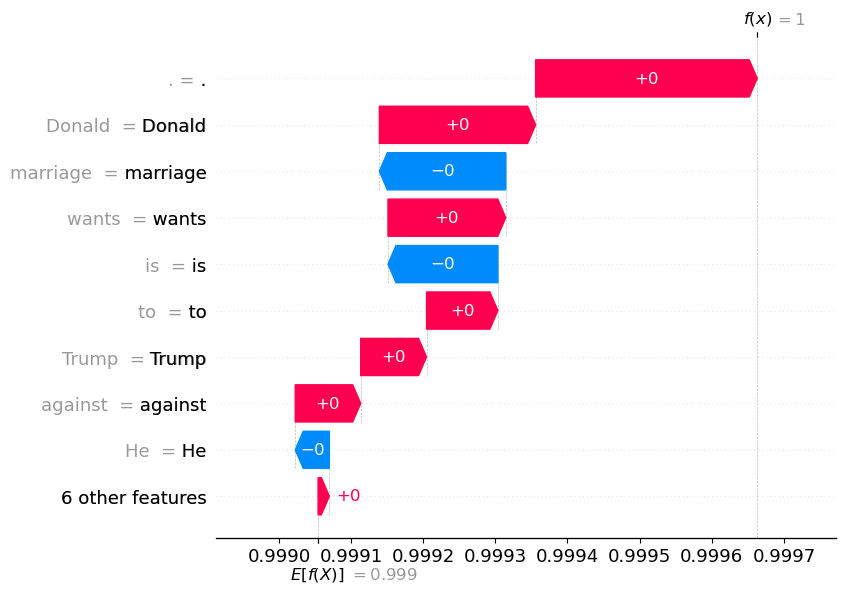


Example 4
True: Fake | Pred: Fake


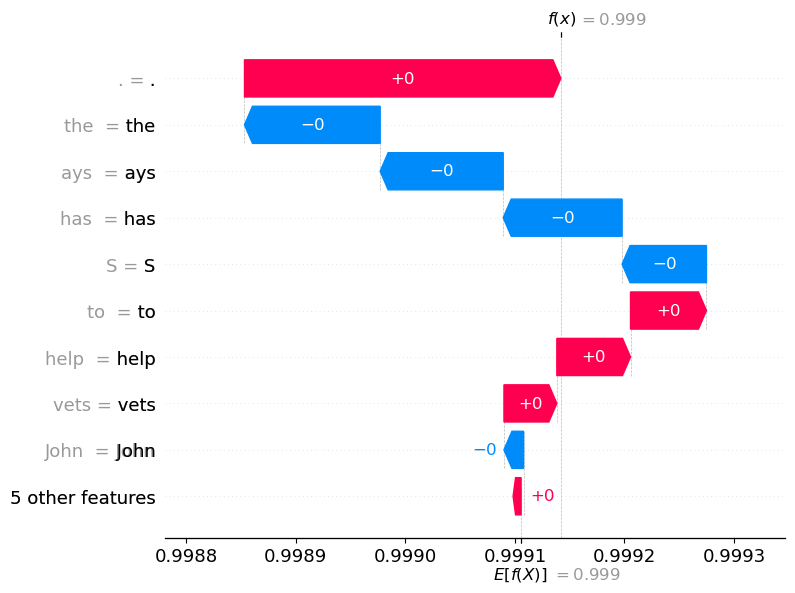


Example 5
True: Real | Pred: Real


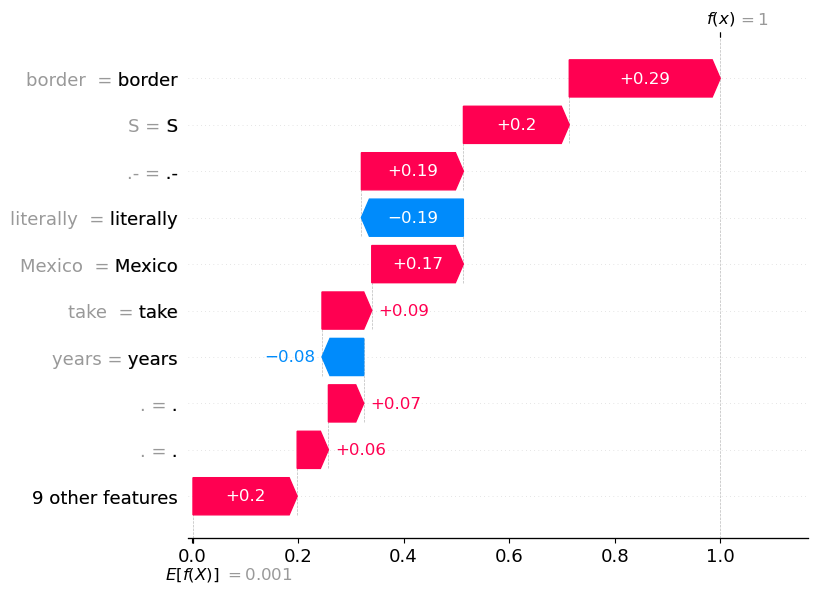


Example 6
True: Real | Pred: Real


  0%|          | 0/498 [00:00<?, ?it/s]

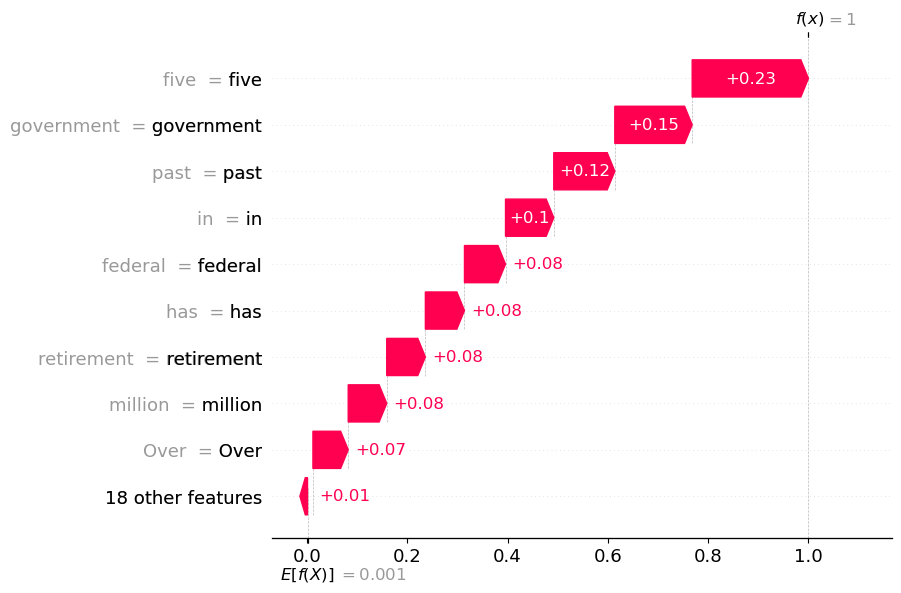

In [69]:
# explain multiple examples using SHAP token attributions
import shap
from transformers import pipeline
import numpy as np

model.to("cpu")
model.eval()

# Define a SHAP prediction function
def predict_shap(texts):
    inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt").to("cpu")
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.detach().numpy()

# Initialize the Explainer
explainer = shap.Explainer(
    predict_shap,
    masker=shap.maskers.Text(tokenizer),
    output_names=['Fake', 'Real']
)

# Split dataset into mistakes and correct predictions
mistakes = clear_news_to_test[
    clear_news_to_test['true_label'] != clear_news_to_test['pred_label']
].copy()

correct = clear_news_to_test[
    clear_news_to_test['true_label'] == clear_news_to_test['pred_label']
].copy()

if mistakes.empty or correct.empty:
    print("Not enough data to generate both correct and incorrect examples.")
else:
    # Ensure class balance (Fake / Real) for BOTH groups

    # mistakes
    fake_mistakes = mistakes[mistakes['true_label'] == 0].head(2)
    real_mistakes = mistakes[mistakes['true_label'] == 1].head(1)

    # correct predictions
    fake_correct = correct[correct['true_label'] == 0].head(1)
    real_correct = correct[correct['true_label'] == 1].head(2)

    selected_indices = np.concatenate([
        fake_mistakes.index,
        real_mistakes.index,
        fake_correct.index,
        real_correct.index
    ])

    print(f"Generating SHAP plots for {len(selected_indices)} examples...")

    # Loop and plot
    for i, idx in enumerate(selected_indices):
        statement = [str(clear_news_to_test.loc[idx, 'statement'])]
        true_label = clear_news_to_test.loc[idx, 'true_label']
        pred_label = clear_news_to_test.loc[idx, 'pred_label']

        print(f"\nExample {i+1}")
        print(f"True: {'Fake' if true_label == 0 else 'Real'} | Pred: {'Fake' if pred_label == 0 else 'Real'}")

        shap_values = explainer(statement)

        target_class = "Fake" if pred_label == 0 else "Real"
        shap.plots.waterfall(shap_values[0, :, target_class])